# Workforce diversity: which US industries are the least diverse?

I used US labour force data (2020–2023) that gives, for every sector and industry, how many people work there and
what share are women, white, Black, Asian and Hispanic/Latino. I wanted to answer six questions:

1. Which sectors look alike?
2. Which sectors are the most male- or female-dominated?
3. Which sectors changed the most between 2021 and 2023?
4. Is any sector dominated by one ethnic group?
5. Are bigger sectors more diverse?
6. Which industries have a similar ethnic mix?

**What I found:**
- **Construction, agriculture and mining stand apart.** They are 88–92% white and mostly men (construction is
  89% men, mining 85%).
- **White workers are the majority in every sector**, from 71% (transportation and utilities) to 92% (agriculture).
- **Education and health is the biggest sector and the most female** (75% women).
- **Mining changed the most** between 2021 and 2023: its Hispanic/Latino share rose about 5 points.
- **At industry level there are four groups:** 70 mostly-white industries, 21 with more Black workers, 14 with
  more Hispanic workers (restaurants, landscaping, food processing) and 5 with many more Asian workers
  (electronics manufacturing, nail salons, pharmaceuticals).

Note: Hispanic/Latino is an ethnicity, not a race, so it overlaps with the other groups and the shares don't add
up to 100%.

## 1. Load the data

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

df = pd.read_csv("../data/raw/dataset-google.csv")

print(df.shape)
print(df.dtypes)
df.head()

(1272, 11)
year                                 float64
sector                                   str
subsector                                str
industry_group                           str
industry                                 str
total_employed_in_thousands          float64
percent_women                        float64
percent_white                        float64
percent_black_or_african_american    float64
percent_asian                        float64
percent_hispanic_or_latino           float64
dtype: object


,year,sector,subsector,industry_group,industry,total_employed_in_thousands,percent_women,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino
0,2022.0,Education and health services,NaN,NaN,NaN,35377.0,0.746,0.745,0.154,0.068,0.137
1,2021.0,Education and health services,NaN,NaN,NaN,34725.0,0.743,0.752,0.148,0.067,0.133
2,2023.0,Manufacturing,NaN,NaN,NaN,15570.0,0.295,0.784,0.108,0.076,0.181
3,2021.0,Transportation and utilities,NaN,NaN,NaN,9377.0,0.248,0.712,0.196,0.055,0.201
4,2021.0,"Total, 16 years and over",NaN,NaN,NaN,152581.0,0.470,0.780,0.120,0.660,0.180


In [2]:
# how many values are missing in each column
df.isnull().sum()

year                                   1
sector                                 1
subsector                             57
industry_group                       257
industry                             765
total_employed_in_thousands            3
percent_women                        140
percent_white                        140
percent_black_or_african_american    140
percent_asian                        140
percent_hispanic_or_latino           140
dtype: int64

## 2. Clean the data

- Some rows are completely blank (no year), so I drop them.
- The row "Total, 16 years and over" is the total of everything, not a sector, so I drop it too.
- Most percentages are stored as decimals (0.875) but a few are whole numbers (87.5). I divide those by 100.
- After that, one row still has an Asian share above 100%, which is impossible, so I drop it.
- The file mixes four levels: sector, subsector, industry group and industry. A **sector** row is one where the
  other three are empty.

In [3]:
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)
df = df[df["sector"] != "Total, 16 years and over"]

pct_cols = ["percent_women", "percent_white", "percent_black_or_african_american", "percent_asian",
            "percent_hispanic_or_latino"]

# fix the percentages that were typed as whole numbers
for col in pct_cols:
    too_big = df[col] > 1
    df.loc[too_big, col] = df.loc[too_big, col] / 100

df = df[df["percent_asian"] <= 1.0]

# sector rows: subsector, industry group and industry are all empty
df_sector = df[df["subsector"].isna() & df["industry_group"].isna() & df["industry"].isna()]

print("Cleaned rows:", len(df))
print("Sector rows:", len(df_sector))
print("Years:", sorted(df["year"].unique().tolist()))
print("Sectors:", df_sector["sector"].nunique())

Cleaned rows: 1128
Sector rows: 52
Years: [2020, 2021, 2022, 2023]
Sectors: 13


## 3. Chart settings

The same colours in every chart.

In [4]:
COLOURS = {
    "white": "#4C78A8",
    "black": "#54A24B",
    "asian": "#EECA3B",
    "hispanic": "#F58518",
    "women_high": "#72B7B2",
    "women_low": "#E45756",
    "parity": "#9E9E9E",
}

ETHNIC_LABELS = {
    "percent_white": "White",
    "percent_black_or_african_american": "Black / African American",
    "percent_asian": "Asian",
    "percent_hispanic_or_latino": "Hispanic / Latino",
}
ethnic_cols = ["percent_white", "percent_black_or_african_american", "percent_asian", "percent_hispanic_or_latino"]
all_demo_cols = ethnic_cols + ["percent_women"]

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor": "#FFFFFF",
    "axes.edgecolor": "#D0D0D0",
    "axes.labelcolor": "#333333",
    "axes.titleweight": "600",
    "axes.titlesize": 14,
    "grid.alpha": 0.3,
    "legend.frameon": False,
})


def save_chart(fig, name):
    """Save a chart into the images/ folder (used in the README)."""
    fig.savefig(f"../images/{name}", dpi=150, bbox_inches="tight")

## Q1. Which sectors look alike?

I group the 13 sectors with **K-Means clustering** on all five percentage columns. First I standardise the columns
(so each has mean 0 and standard deviation 1), otherwise the bigger numbers would count more. To choose the number
of groups I use the **elbow method**: I try 1 to 10 groups and look for where the line stops dropping quickly.

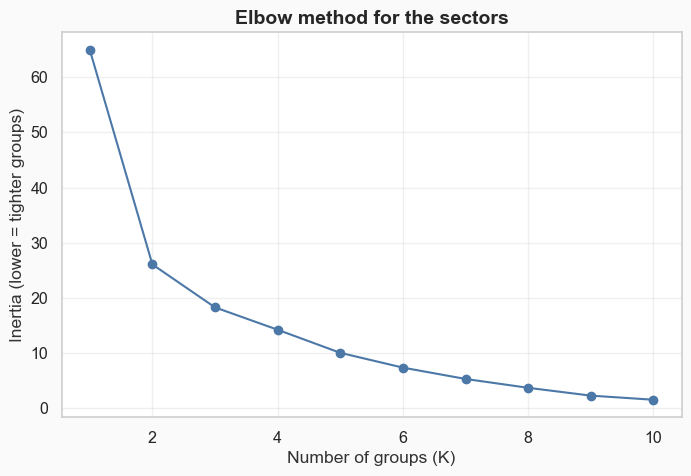

In [5]:
# one row per sector: the average of 2020-2023
sectors = df_sector.groupby("sector")[all_demo_cols].mean()

scaler = StandardScaler()
X_sectors = scaler.fit_transform(sectors)

inertia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_sectors)
    inertia.append(model.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 11), inertia, marker="o", color=COLOURS["white"])
ax.set_xlabel("Number of groups (K)")
ax.set_ylabel("Inertia (lower = tighter groups)")
ax.set_title("Elbow method for the sectors")
plt.show()

The line bends at about 3, so I use 3 groups.

In [6]:
kmeans_sectors = KMeans(n_clusters=3, random_state=42, n_init=10)
sectors["cluster"] = kmeans_sectors.fit_predict(X_sectors)

print(sectors["cluster"].value_counts().sort_index())
print()
print(sectors.groupby("cluster")[all_demo_cols].mean().round(3))
print()
for cluster in [0, 1, 2]:
    names = sectors[sectors["cluster"] == cluster].index.tolist()
    print(f"Group {cluster}: {names}")

cluster
0    2
1    8
2    3
Name: count, dtype: int64

         percent_white  percent_black_or_african_american  percent_asian  \
cluster                                                                    
0                0.718                              0.189          0.052   
1                0.771                              0.117          0.078   
2                0.892                              0.051          0.021   

         percent_hispanic_or_latino  percent_women  
cluster                                             
0                             0.167          0.353  
1                             0.172          0.481  
2                             0.256          0.183  

Group 0: ['Public administration', 'Transportation and utilities']
Group 1: ['Education and health services', 'Financial activities', 'Information', 'Leisure and hospitality', 'Manufacturing', 'Other services', 'Professional and business services', 'Wholesale and retail trade']
Group 2: ['Agricul

The two PCA axes keep 83% of the information


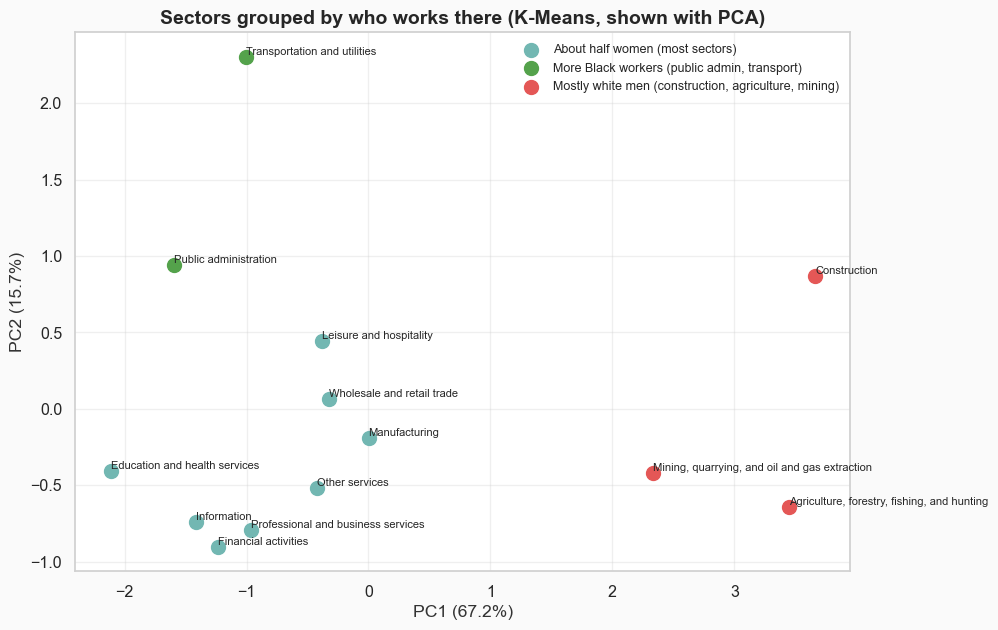

In [7]:
# PCA squeezes the 5 columns into 2, so the sectors can be drawn on a flat chart
pca_sectors = PCA(n_components=2)
points = pca_sectors.fit_transform(X_sectors)
explained = pca_sectors.explained_variance_ratio_ * 100
print(f"The two PCA axes keep {explained.sum():.0f}% of the information")

# names for the groups, from the table above
sector_group_names = {
    0: "More Black workers (public admin, transport)",
    1: "About half women (most sectors)",
    2: "Mostly white men (construction, agriculture, mining)",
}
sector_group_colours = {0: COLOURS["black"], 1: COLOURS["women_high"], 2: COLOURS["women_low"]}

fig, ax = plt.subplots(figsize=(10, 7))
for cluster in [1, 0, 2]:
    in_group = (sectors["cluster"] == cluster).values
    ax.scatter(points[in_group, 0], points[in_group, 1], s=100, color=sector_group_colours[cluster],
               label=sector_group_names[cluster])
for i in range(len(sectors)):
    ax.annotate(sectors.index[i], (points[i, 0], points[i, 1]), fontsize=8, ha="left", va="bottom")
ax.legend(loc="best", fontsize=9)
ax.set_xlabel(f"PC1 ({explained[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}%)")
ax.set_title("Sectors grouped by who works there (K-Means, shown with PCA)")
save_chart(fig, "03_sector_groups.png")
plt.show()

**Q1 answer.** The two PCA axes keep 83% of the information, so the chart is a fair picture.

| Group | Sectors | What they have in common |
|---|---|---|
| 2 | Agriculture, Construction, Mining | 89% white, 26% Hispanic/Latino, only 18% women |
| 1 | 8 sectors, incl. Education & health, Financial, Manufacturing | 77% white, about half women (48%) |
| 0 | Public administration, Transportation & utilities | the most Black workers (19%), 35% women |

Most sectors look similar. Construction, agriculture and mining are the outliers.

## Q2. Which sectors are the most male- or female-dominated?

I measure how far each sector is from 50/50, and also weight that gap by the sector's size, because a big sector
that is unbalanced affects more people.

In [8]:
gender = df_sector.groupby("sector").agg(
    percent_women=("percent_women", "mean"),
    total_employed=("total_employed_in_thousands", "sum"),
)
gender["share_of_all_workers"] = gender["total_employed"] / gender["total_employed"].sum()
gender["gap_from_50_50"] = abs(gender["percent_women"] - 0.5)
gender["weighted_gap"] = gender["gap_from_50_50"] * gender["share_of_all_workers"]

gender.sort_values("weighted_gap", ascending=False).head(5)

,percent_women,total_employed,share_of_all_workers,gap_from_50_50,weighted_gap
sector,,,,,
Education and health services,0.74575,140585.0,0.226860,0.24575,0.055751
Construction,0.10925,45743.0,0.073815,0.39075,0.028843
Manufacturing,0.29500,60069.0,0.096933,0.20500,0.019871
Transportation and utilities,0.24625,37957.0,0.061251,0.25375,0.015542
Professional and business services,0.42050,79474.0,0.128246,0.07950,0.010196


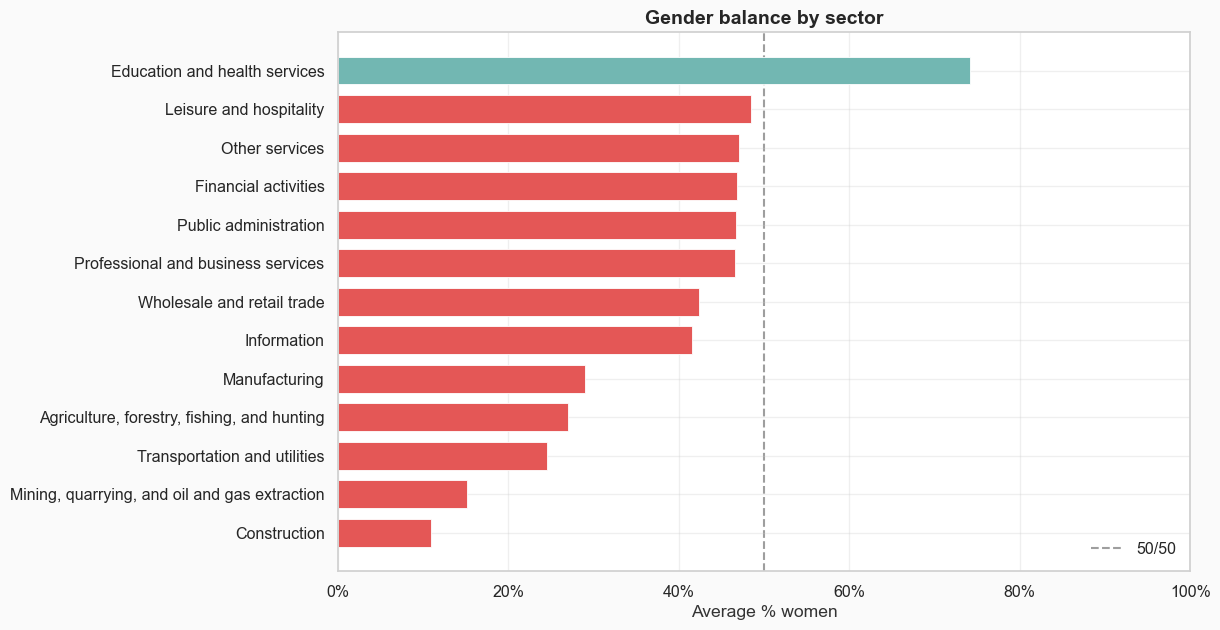

In [9]:
# Chart: average % women in each sector (red = fewer than half, teal = more than half)
women = df.groupby("sector")["percent_women"].mean().sort_values()

bar_colours = []
for value in women.values:
    if value < 0.5:
        bar_colours.append(COLOURS["women_low"])
    else:
        bar_colours.append(COLOURS["women_high"])

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(women.index, women.values * 100, color=bar_colours, edgecolor="white", linewidth=0.6, height=0.72)
ax.axvline(x=50, color=COLOURS["parity"], linestyle="--", linewidth=1.5, label="50/50", zorder=0)
ax.set_xlim(0, 100)
ax.set_xlabel("Average % women")
ax.set_title("Gender balance by sector")
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.legend(loc="lower right")
save_chart(fig, "01_gender_balance.png")
plt.show()

**Q2 answer.** Construction is the most male sector (11% women, so 89% men), then mining (15%) and transportation
and utilities (25%). Education and health is the most female (75% women), and because it is also the biggest
sector (23% of all workers), it has the biggest weighted gap.

## Q3. Which sectors changed the most between 2021 and 2023?

For each sector I subtract the 2021 percentages from the 2023 ones, then add up the size of all five changes.

In [10]:
year_2021 = df_sector[df_sector["year"] == 2021].set_index("sector")
year_2023 = df_sector[df_sector["year"] == 2023].set_index("sector")

change = year_2023[all_demo_cols] - year_2021[all_demo_cols]
change["total_change"] = change[all_demo_cols].abs().sum(axis=1)

# in percentage points
(change.sort_values("total_change", ascending=False).head(6) * 100).round(1)

,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino,percent_women,total_change
sector,,,,,,
"Mining, quarrying, and oil and gas extraction",0.8,0.4,-0.8,5.4,-0.1,7.5
Financial activities,-1.9,0.7,1.2,0.2,-1.0,5.0
Professional and business services,-1.7,1.1,0.2,1.0,-0.4,4.4
Leisure and hospitality,-1.3,0.6,0.5,1.7,-0.1,4.2
Other services,-0.4,0.4,0.1,1.8,1.4,4.1
Information,-0.8,-0.6,1.0,0.4,-1.0,3.8


**Q3 answer.** Mining changed the most (7.5 points in total), mostly because its Hispanic/Latino share rose
5.4 points. Financial activities came next (5.0), with the white share down 1.9 points and the Asian share up 1.2.
These are small changes, but most of them point towards a more mixed workforce.

## Q4. Is any sector dominated by one ethnic group?

In [11]:
ethnic = df_sector.groupby("sector")[ethnic_cols].mean()
ethnic["biggest_group"] = ethnic[ethnic_cols].idxmax(axis=1)
ethnic["biggest_share"] = ethnic[ethnic_cols].max(axis=1)
ethnic.sort_values("biggest_share", ascending=False)

,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino,biggest_group,biggest_share
sector,,,,,,
"Agriculture, forestry, fishing, and hunting",0.92050,0.03175,0.01025,0.24850,percent_white,0.92050
Construction,0.87925,0.06425,0.01975,0.32700,percent_white,0.87925
"Mining, quarrying, and oil and gas extraction",0.87575,0.05650,0.03350,0.19350,percent_white,0.87575
Manufacturing,0.79150,0.10475,0.07275,0.17475,percent_white,0.79150
Other services,0.78500,0.10350,0.07700,0.20825,percent_white,0.78500
Wholesale and retail trade,0.77975,0.12175,0.06075,0.18950,percent_white,0.77975
Financial activities,0.77900,0.11400,0.08050,0.12775,percent_white,0.77900
Professional and business services,0.76925,0.10225,0.09875,0.16775,percent_white,0.76925
Information,0.75725,0.11425,0.09800,0.12725,percent_white,0.75725


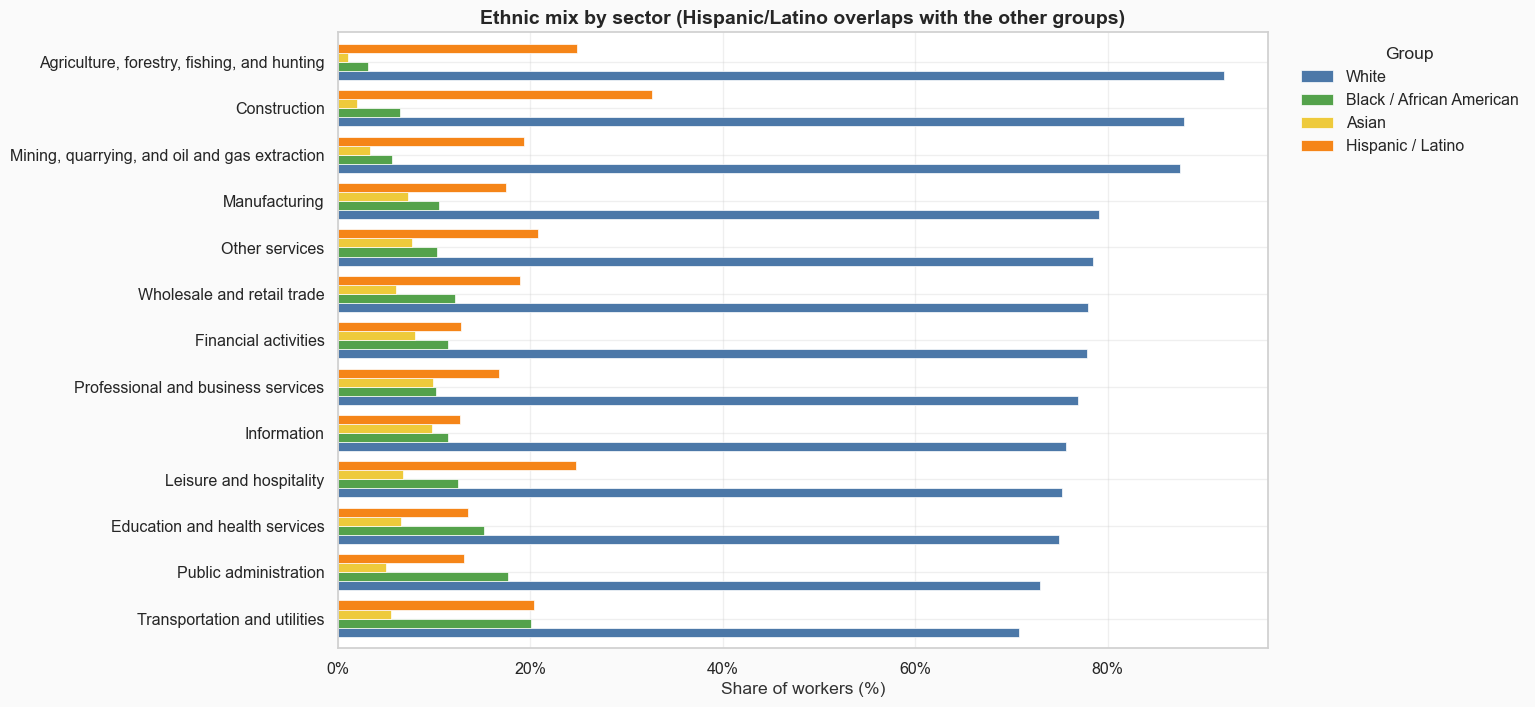

In [12]:
# Chart: the ethnic mix of each sector
chart_data = ethnic[ethnic_cols] * 100
chart_data = chart_data.sort_values("percent_white")
chart_data = chart_data.rename(columns=ETHNIC_LABELS)

fig, ax = plt.subplots(figsize=(12, 8))
chart_data.plot(kind="barh", ax=ax, color=[COLOURS["white"], COLOURS["black"], COLOURS["asian"], COLOURS["hispanic"]],
                width=0.78, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Share of workers (%)")
ax.set_ylabel("")
ax.set_title("Ethnic mix by sector (Hispanic/Latino overlaps with the other groups)")
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Group")
save_chart(fig, "02_ethnic_mix.png")
plt.show()

**Q4 answer.** Yes: white workers are the biggest group in every sector. The share goes from 71% (transportation
and utilities) to 92% (agriculture). Agriculture (92%), construction (88%) and mining (88%) are the most one-sided.
Construction also has the highest Hispanic/Latino share (33%).

## Q5. Are bigger sectors more diverse?

To give each sector one "diversity score" I use **Shannon entropy**: it is higher when workers are spread more
evenly across the groups.

In [13]:
def diversity_score(shares):
    """Shannon entropy: minus the sum of p x log(p) over the groups."""
    total = 0
    for p in shares:
        if p > 0:
            total = total - p * np.log(p)
    return total


ethnic["diversity_score"] = ethnic[ethnic_cols].apply(diversity_score, axis=1)
ethnic["avg_employed_thousands"] = df_sector.groupby("sector")["total_employed_in_thousands"].mean()

correlation = ethnic["diversity_score"].corr(ethnic["avg_employed_thousands"])
print(f"Correlation between diversity and size: {correlation:.2f}")
ethnic[["diversity_score", "avg_employed_thousands"]].sort_values("diversity_score", ascending=False).round(2)

Correlation between diversity and size: 0.42


,diversity_score,avg_employed_thousands
sector,,
Transportation and utilities,1.05,9489.25
Leisure and hospitality,1.00,13032.75
Professional and business services,0.96,19868.50
Public administration,0.95,7642.25
Education and health services,0.95,35146.25
Other services,0.95,7265.75
Information,0.95,2788.25
Wholesale and retail trade,0.94,19465.25
Manufacturing,0.92,15017.25


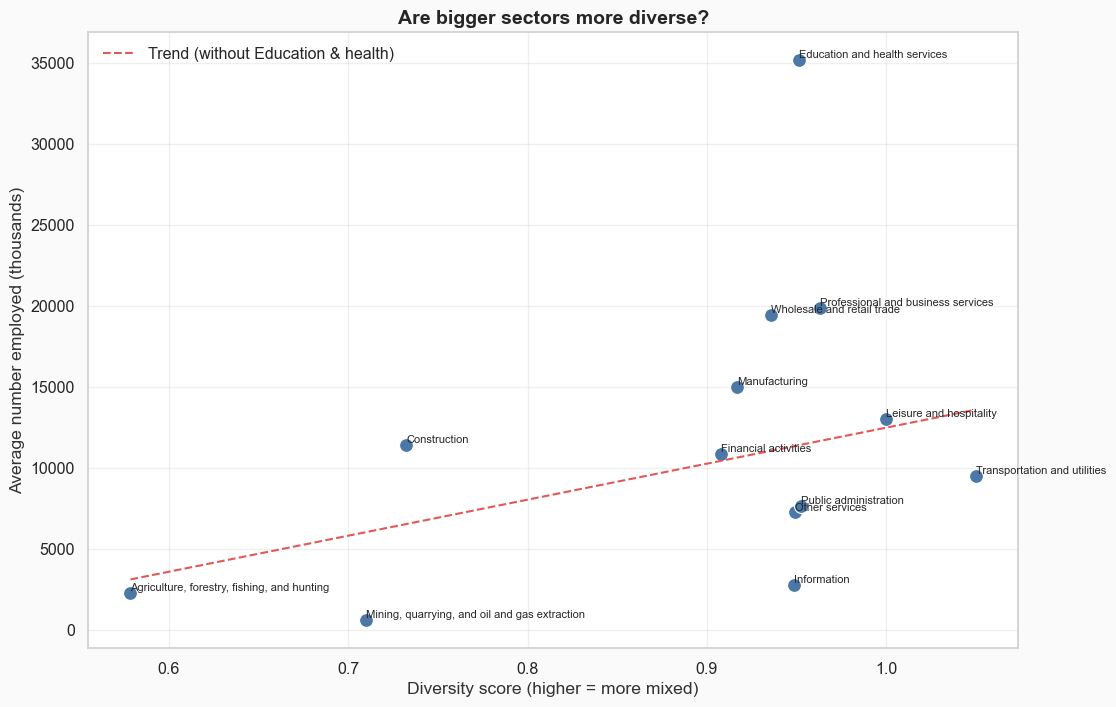

In [14]:
# Chart: diversity score vs size, one dot per sector
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(ethnic["diversity_score"], ethnic["avg_employed_thousands"], s=100, color=COLOURS["white"],
           edgecolor="white", linewidth=0.8)
for sector_name in ethnic.index:
    x = ethnic.loc[sector_name, "diversity_score"]
    y = ethnic.loc[sector_name, "avg_employed_thousands"]
    ax.annotate(sector_name, (x, y), fontsize=8, ha="left", va="bottom")

# trend line, leaving out Education & health because it is so much bigger than the rest
others = ethnic[ethnic.index != "Education and health services"]
slope, intercept = np.polyfit(others["diversity_score"], others["avg_employed_thousands"], 1)
x_line = np.linspace(ethnic["diversity_score"].min(), ethnic["diversity_score"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color=COLOURS["women_low"], linestyle="--", linewidth=1.5,
        label="Trend (without Education & health)")

ax.set_xlabel("Diversity score (higher = more mixed)")
ax.set_ylabel("Average number employed (thousands)")
ax.set_title("Are bigger sectors more diverse?")
ax.legend()
save_chart(fig, "04_diversity_vs_size.png")
plt.show()

**Q5 answer.** A little. The correlation is 0.42, so bigger sectors tend to be somewhat more mixed, but it is a
weak link with only 13 sectors. Transportation and utilities is the most diverse. Agriculture and mining are the
least diverse and also two of the smallest sectors; construction is mid-sized but almost as one-sided.

## Q6. Which industries have a similar ethnic mix?

Now I use the **industry** rows (110 industries) instead of the 13 sectors, and group them on the four ethnic
columns only.

Industries: 110


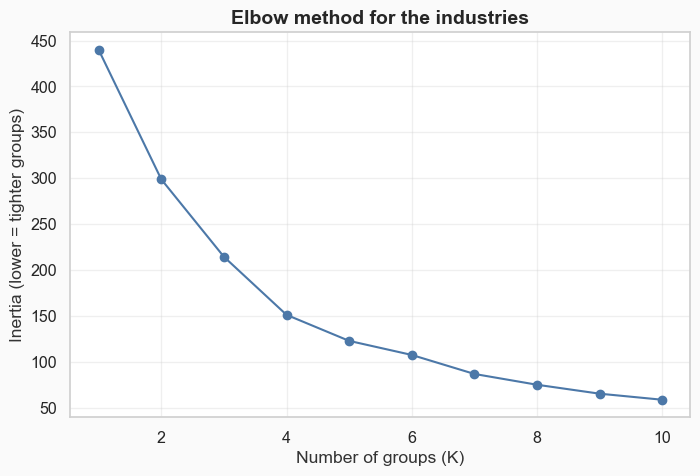

In [15]:
df_industry = df[df["industry"].notna()]
industries = df_industry.groupby("industry")[ethnic_cols].mean().dropna()
print("Industries:", len(industries))

X_industries = scaler.fit_transform(industries)

inertia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_industries)
    inertia.append(model.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 11), inertia, marker="o", color=COLOURS["white"])
ax.set_xlabel("Number of groups (K)")
ax.set_ylabel("Inertia (lower = tighter groups)")
ax.set_title("Elbow method for the industries")
plt.show()

In [16]:
kmeans_industries = KMeans(n_clusters=4, random_state=42, n_init=10)
industries["cluster"] = kmeans_industries.fit_predict(X_industries)

print(industries["cluster"].value_counts().sort_index())
print()
print(industries.groupby("cluster")[ethnic_cols].mean().round(3))
print()
for cluster in [0, 1, 2, 3]:
    names = industries[industries["cluster"] == cluster].index.tolist()
    print(f"Group {cluster} ({len(names)} industries), for example: {names[:6]}")
    print()

cluster
0    14
1     5
2    70
3    21
Name: count, dtype: int64

         percent_white  percent_black_or_african_american  percent_asian  \
cluster                                                                    
0                0.739                              0.149          0.070   
1                0.630                              0.075          0.264   
2                0.833                              0.087          0.048   
3                0.698                              0.217          0.048   

         percent_hispanic_or_latino  
cluster                              
0                             0.348  
1                             0.117  
2                             0.166  
3                             0.144  

Group 0 (14 industries), for example: ['Animal slaughtering and processing', 'Bakeries and tortilla manufacturing, except retail bakeries', 'Barber shops', 'Car washes', 'Cut and sew, and apparel accessories and other apparel manufacturing', 'Dryc

The two PCA axes keep 77% of the information


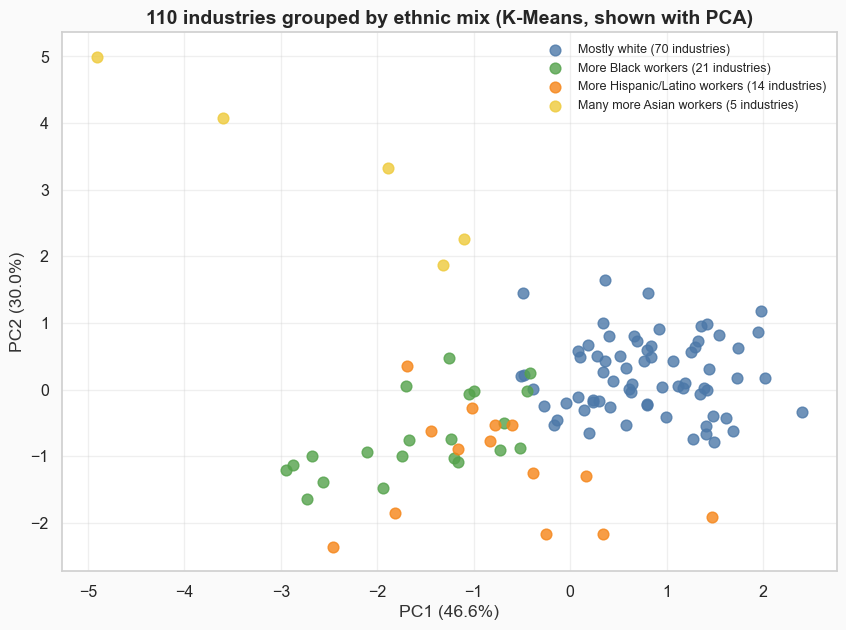

In [17]:
pca_industries = PCA(n_components=2)
points = pca_industries.fit_transform(X_industries)
explained = pca_industries.explained_variance_ratio_ * 100
print(f"The two PCA axes keep {explained.sum():.0f}% of the information")

# names for the groups, from the table above
industry_group_names = {
    0: "More Hispanic/Latino workers",
    1: "Many more Asian workers",
    2: "Mostly white",
    3: "More Black workers",
}
industry_group_colours = {0: COLOURS["hispanic"], 1: COLOURS["asian"], 2: COLOURS["white"], 3: COLOURS["black"]}

fig, ax = plt.subplots(figsize=(10, 7))
for cluster in [2, 3, 0, 1]:
    in_group = (industries["cluster"] == cluster).values
    label = f"{industry_group_names[cluster]} ({in_group.sum()} industries)"
    ax.scatter(points[in_group, 0], points[in_group, 1], s=60, alpha=0.8, color=industry_group_colours[cluster],
               label=label)
ax.legend(loc="best", fontsize=9)
ax.set_xlabel(f"PC1 ({explained[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}%)")
ax.set_title("110 industries grouped by ethnic mix (K-Means, shown with PCA)")
save_chart(fig, "05_industry_groups.png")
plt.show()

**Q6 answer.** The two PCA axes keep 77% of the information.

| Group | Industries | What stands out | Examples |
|---|---:|---|---|
| 2 | 70 | mostly white (83%) | aerospace, insurance, car repair |
| 3 | 21 | more Black workers (22%) | hospitals, home health care, security services |
| 0 | 14 | more Hispanic/Latino workers (35%) | restaurants, landscaping, food processing |
| 1 | 5 | many more Asian workers (26%) | computer and electronics manufacturing, nail salons, pharmaceuticals |

## Summary

- Construction, agriculture and mining are the least diverse sectors: mostly white and mostly men. If a company
  wants to start a diversity hiring program, these are the places where it would change the most.
- White workers are the majority everywhere, so "more diverse" here means "more mixed", not "balanced".
- Things are moving slowly: the biggest change from 2021 to 2023 was mining's Hispanic/Latino share (+5 points).

**Limitations**
- Only four years of data, and the groups overlap (Hispanic/Latino can be any race).
- The percentages are survey estimates, so small industries can jump around from year to year.
- K-Means always finds groups, even weak ones, so the groups describe the data rather than prove anything.